# Testing DTR Environment

This notebook demonstrates the key features of the DTR environment, which simulates a two-stage medical treatment scenario. We'll test:

1. Basic treatment stages and transitions
2. Effects of confounding on treatment decisions
3. Different behavioral and interventional policies
4. Analysis of treatment outcomes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from causal_gym.envs import DTRPCH as DTRExamplePCH
import warnings
warnings.filterwarnings("ignore", category=UserWarning,
                      message="Overriding environment .* already in registry")

In [2]:
# Parameters
N_EPISODES = 1000

In [3]:
def run_observational(env, n_episodes):
    """Run episodes under observational policy"""
    trajectories = []
    print("Running Observational...")
    
    for ep in range(n_episodes):
        if (ep + 1) % (n_episodes // 10) == 0:
            print(f"  Episode {ep + 1}/{n_episodes}")
            
        s1, _ = env.reset()
        trajectory = {'s1': s1}
        
        # First stage
        s2, r, term, _, info = env.see()
        trajectory.update({
            'x1': info['x1'],
            's2': s2
        })
        
        # Second stage
        _, r, term, _, info = env.see()
        trajectory.update({
            'x2': info['x2'],
            'y': info['y']
        })
        
        trajectories.append(trajectory)
        
    print("Finished observational run.")
    return trajectories

def run_interventional(env, n_episodes, policy1, policy2):
    """Run episodes with fixed intervention policies"""
    trajectories = []
    print("Running Interventional...")
    
    for ep in range(n_episodes):
        if (ep + 1) % (n_episodes // 10) == 0:
            print(f"  Episode {ep + 1}/{n_episodes}")
            
        s1, _ = env.reset()
        trajectory = {'s1': s1}
        
        # First stage
        s2, r, term, _, info = env.do(policy1)
        trajectory.update({
            'x1': info['x1'],
            's2': s2
        })
        
        # Second stage
        _, r, term, _, info = env.do(policy2)
        trajectory.update({
            'x2': info['x2'],
            'y': info['y']
        })
        
        trajectories.append(trajectory)
        
    print("Finished interventional run.")
    return trajectories

## Test 1: No Confounding

First, let's test the environment without confounding (a1=a2=0).

In [4]:
# Create environment without confounding
env = DTRExamplePCH(a1=0, a2=0)

# Run observational policy
obs_trajectories = run_observational(env, N_EPISODES)

# Convert trajectories to numpy arrays for analysis
obs_data = {
    's1': np.array([t['s1'] for t in obs_trajectories]),
    'x1': np.array([t['x1'] for t in obs_trajectories]),
    's2': np.array([t['s2'] for t in obs_trajectories]),
    'x2': np.array([t['x2'] for t in obs_trajectories]),
    'y': np.array([t['y'] for t in obs_trajectories])
}

print("\nObservational Results (No Confounding):")
print(f"Average outcome: {obs_data['y'].mean():.3f}")
print(f"Treatment 1 distribution: {np.bincount(obs_data['x1']) / len(obs_data['x1'])}")
print(f"Treatment 2 distribution: {np.bincount(obs_data['x2']) / len(obs_data['x2'])}")
print(f"Response rate: {obs_data['s2'].mean():.3f}")

Running Observational...
  Episode 100/1000
  Episode 200/1000
  Episode 300/1000
  Episode 400/1000
  Episode 500/1000
  Episode 600/1000
  Episode 700/1000
  Episode 800/1000
  Episode 900/1000
  Episode 1000/1000
Finished observational run.

Observational Results (No Confounding):
Average outcome: 0.443
Treatment 1 distribution: [0.281 0.719]
Treatment 2 distribution: [0.267 0.733]
Response rate: 0.548


## Test 2: With Confounding

Now let's test with confounding enabled.

In [5]:
# Create environment with confounding
env = DTRExamplePCH(a1=0.5, a2=0.5)

# Define simple intervention policies
def always_medication(s1):
    return 1  # Always use medication

def response_based_followup(s1, x1, s2):
    return 1 if s2 == 0 else 0  # Intensive therapy for non-responders

# Run both observational and interventional
obs_trajectories = run_observational(env, N_EPISODES)
int_trajectories = run_interventional(env, N_EPISODES, always_medication, response_based_followup)

# Convert to numpy arrays
obs_data = {
    's1': np.array([t['s1'] for t in obs_trajectories]),
    'x1': np.array([t['x1'] for t in obs_trajectories]),
    's2': np.array([t['s2'] for t in obs_trajectories]),
    'x2': np.array([t['x2'] for t in obs_trajectories]),
    'y': np.array([t['y'] for t in obs_trajectories])
}

int_data = {
    's1': np.array([t['s1'] for t in int_trajectories]),
    'x1': np.array([t['x1'] for t in int_trajectories]),
    's2': np.array([t['s2'] for t in int_trajectories]),
    'x2': np.array([t['x2'] for t in int_trajectories]),
    'y': np.array([t['y'] for t in int_trajectories])
}

print("\nComparison with Confounding:")
print("Observational:")
print(f"  Average outcome: {obs_data['y'].mean():.3f}")
print(f"  Response rate: {obs_data['s2'].mean():.3f}")
print("\nInterventional:")
print(f"  Average outcome: {int_data['y'].mean():.3f}")
print(f"  Response rate: {int_data['s2'].mean():.3f}")

Running Observational...
  Episode 100/1000
  Episode 200/1000
  Episode 300/1000
  Episode 400/1000
  Episode 500/1000
  Episode 600/1000
  Episode 700/1000
  Episode 800/1000
  Episode 900/1000
  Episode 1000/1000
Finished observational run.
Running Interventional...
  Episode 100/1000
  Episode 200/1000
  Episode 300/1000
  Episode 400/1000
  Episode 500/1000
  Episode 600/1000
  Episode 700/1000
  Episode 800/1000
  Episode 900/1000
  Episode 1000/1000
Finished interventional run.

Comparison with Confounding:
Observational:
  Average outcome: 0.454
  Response rate: 0.557

Interventional:
  Average outcome: 0.251
  Response rate: 0.560


## Test 3: Treatment Response Analysis

Let's analyze how different treatment combinations affect outcomes.

Observational Analysis:

Outcomes by initial condition (S1):
S1 = 0:
  Average outcome: 0.896
  Response rate: 0.557
S1 = 1:
  Average outcome: 0.014
  Response rate: 0.557

Outcomes by treatment combination (X1, X2):
X1 = 0, X2 = 0:
  Average outcome: 0.926
  Count: 54
X1 = 0, X2 = 1:
  Average outcome: 0.973
  Count: 188
X1 = 1, X2 = 0:
  Average outcome: 0.000
  Count: 139
X1 = 1, X2 = 1:
  Average outcome: 0.357
  Count: 619

Interventional Analysis:

Outcomes by initial condition (S1):
S1 = 0:
  Average outcome: 0.485
  Response rate: 0.515
S1 = 1:
  Average outcome: 0.000
  Response rate: 0.609

Outcomes by treatment combination (X1, X2):
X1 = 1, X2 = 0:
  Average outcome: 0.000
  Count: 560
X1 = 1, X2 = 1:
  Average outcome: 0.570
  Count: 440


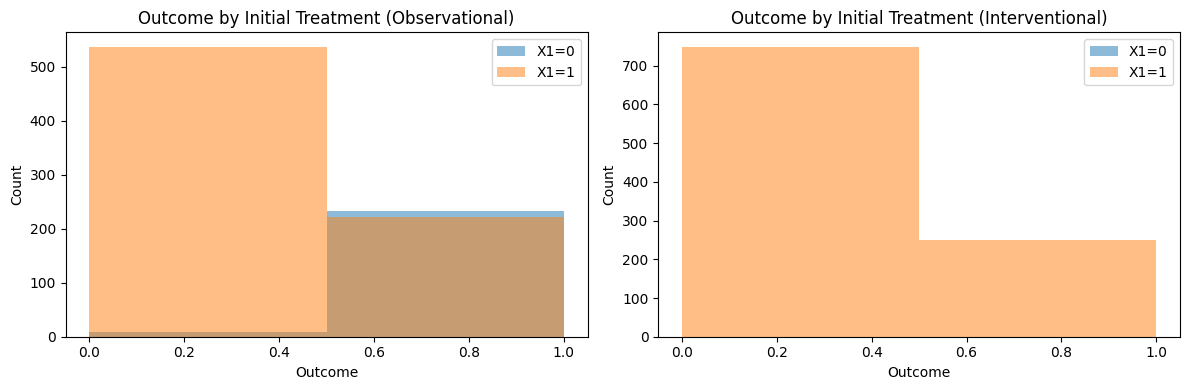

In [6]:
def analyze_treatment_effects(data):
    """Analyze treatment effects for different patient groups"""
    # Initial condition effects
    print("\nOutcomes by initial condition (S1):")
    for s1 in [0, 1]:
        mask = data['s1'] == s1
        print(f"S1 = {s1}:")
        print(f"  Average outcome: {data['y'][mask].mean():.3f}")
        print(f"  Response rate: {data['s2'][mask].mean():.3f}")
    
    # Treatment combination effects
    print("\nOutcomes by treatment combination (X1, X2):")
    for x1 in [0, 1]:
        for x2 in [0, 1]:
            mask = (data['x1'] == x1) & (data['x2'] == x2)
            if mask.any():
                print(f"X1 = {x1}, X2 = {x2}:")
                print(f"  Average outcome: {data['y'][mask].mean():.3f}")
                print(f"  Count: {mask.sum()}")

print("Observational Analysis:")
analyze_treatment_effects(obs_data)

print("\nInterventional Analysis:")
analyze_treatment_effects(int_data)

# Plot outcome distributions
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
for x1 in [0, 1]:
    mask = obs_data['x1'] == x1
    plt.hist(obs_data['y'][mask], alpha=0.5, 
             label=f'X1={x1}', bins=2)
plt.title('Outcome by Initial Treatment (Observational)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 2, 2)
for x1 in [0, 1]:
    mask = int_data['x1'] == x1
    plt.hist(int_data['y'][mask], alpha=0.5, 
             label=f'X1={x1}', bins=2)
plt.title('Outcome by Initial Treatment (Interventional)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.show()